In [1]:
from email.utils import encode_rfc2231
from encodings import latin_1
from pickle import FALSE

import numpy as np
import pandas as pd
from scipy.spatial.transform import rotation
from sklearn import pipeline
from sklearn.utils._repr_html import estimator
from sklearn.utils.multiclass import type_of_target

In [2]:
df = pd.read_csv(r'F:\University\Fourth Sem\Artificial Intelligence\SMS spam Checker\spam.csv', encoding='latin_1')

In [3]:
df.shape

(5572, 5)

# 1. Data Cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model building
# 5. Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy


# 1.Data Cleaning

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [5]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'], inplace=True)

In [6]:
# renaming the columns
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(10)

,target,text
2159,spam,FREE for 1st week! No1 Nokia tone 4 ur mob eve...
3818,ham,"sorry brah, just finished the last of my exams..."
4822,ham,:-) :-)
2140,ham,After the drug she will be able to eat.
2679,spam,"New Tones This week include: 1)McFly-All Ab..,..."
3397,ham,It only does simple arithmetic not percentages.
4762,ham,Prepare to be pleasured :)
4492,ham,"LOL .. *grins* .. I'm not babe, but thanks for..."
3150,ham,Yeah but which is worse for i
2060,ham,I did. One slice and one breadstick. Lol


In [7]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [8]:
df['target'] = encoder.fit_transform(df['target'])

In [9]:
# checking missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [10]:
# check duplicte value
df.duplicated().sum()

np.int64(403)

In [11]:
df = df.drop_duplicates(keep='first')

# 1. EDA

In [12]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


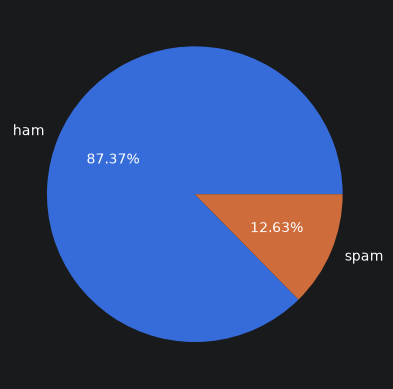

In [13]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham','spam'], autopct="%0.2f%%")

In [14]:
# Data is imbalance

In [15]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\muzam\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\muzam\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\muzam\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [16]:
df['num_character'] = df['text'].apply(len)

In [17]:
df.head()

,target,text,num_character
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [18]:
# num of words

In [19]:
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [20]:
df.head()

,target,text,num_character,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [21]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [22]:
df.head()

,target,text,num_character,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [23]:
df[['num_character','num_words','num_sentences']].describe()

,num_character,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [24]:
# Ham messages
df[df['target'] == 0][['num_character','num_words','num_sentences']].describe()

,num_character,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [25]:
#  Spam messages
df[df['target'] == 1][['num_character','num_words','num_sentences']].describe()

,num_character,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [26]:
import seaborn as sns

<Axes: xlabel='num_character', ylabel='Count'>

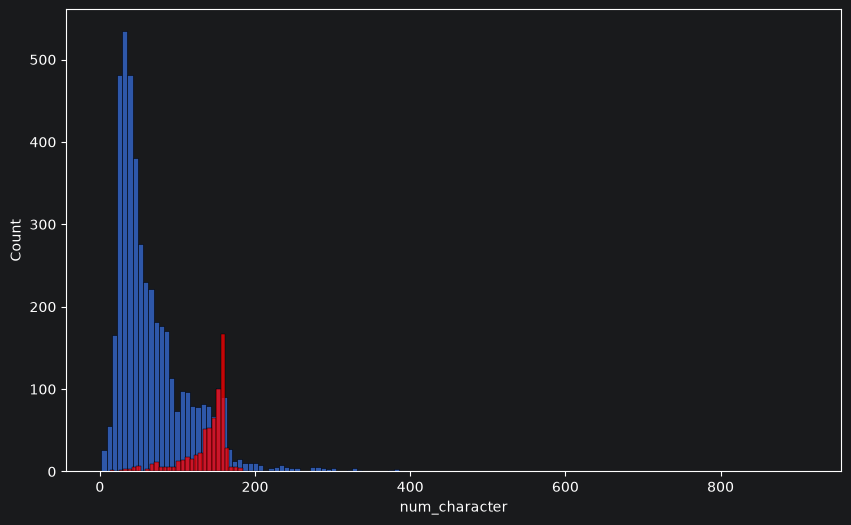

In [27]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['target'] == 0]['num_character'])
sns.histplot(df[df['target'] == 1]['num_character'], color='red')

<Axes: xlabel='num_words', ylabel='Count'>

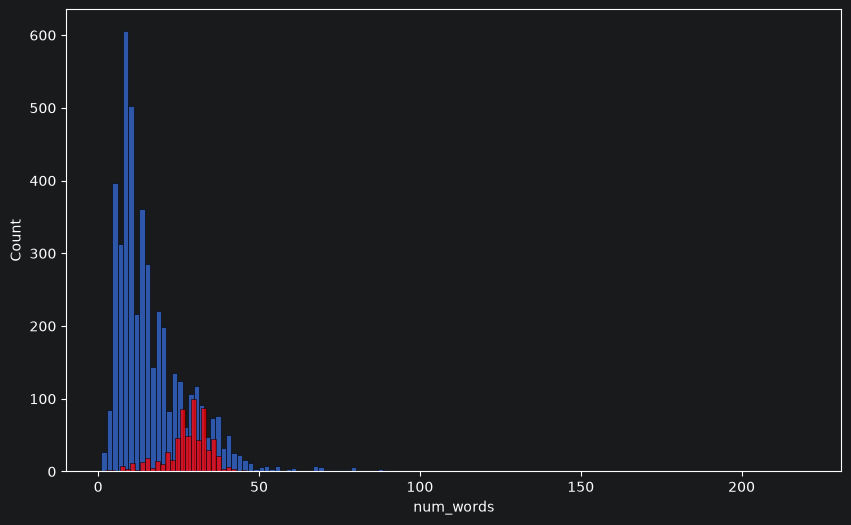

In [28]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'], color='red')

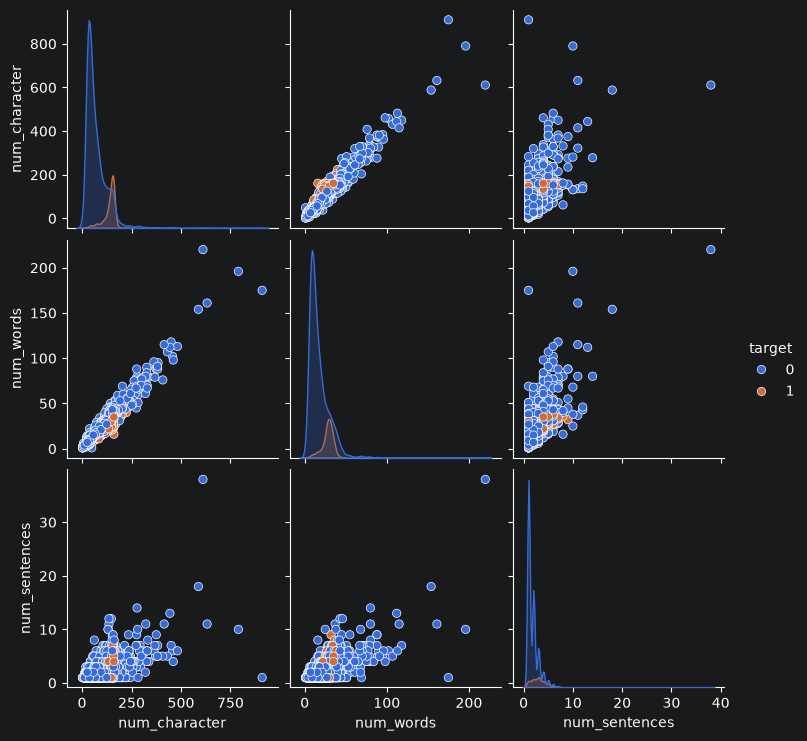

In [29]:
sns.pairplot(df, hue='target')

<Axes: >

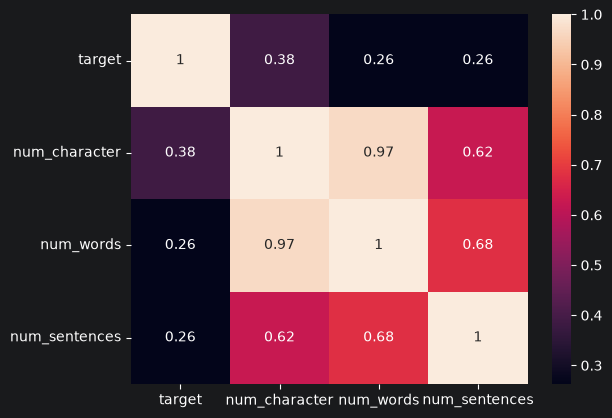

In [30]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)

# 3. Data Preprocessing
  - lower case
  - Tokenization
  - Removing special characters
  - Removing stop words and punctuation

In [31]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import nltk
import string

ps = PorterStemmer()
stop_words = stopwords.words('english')
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []

    # Remove special characters
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    # Remove stopwords and punctuation
    for i in text:
        if i not in stop_words and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    # Stemming
    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)


transform_text("My name is Muzammil AHmed Ansari and i am working on a Machine Learning Project")


'name muzammil ahm ansari work machin learn project'

In [32]:
df['transformed_text'] = df['text'].apply(transform_text)

In [33]:
df.head()

,target,text,num_character,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [34]:
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

In [35]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

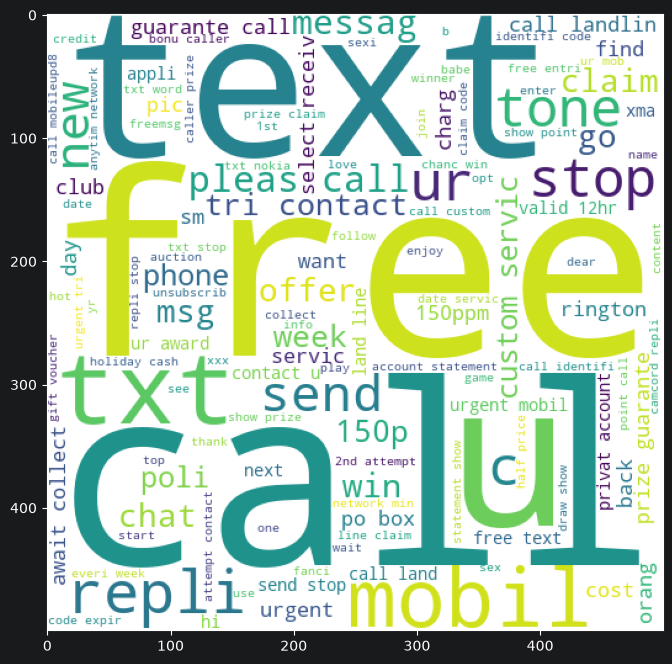

In [36]:
plt.figure(figsize=(12,8))
plt.imshow(spam_wc)

In [37]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

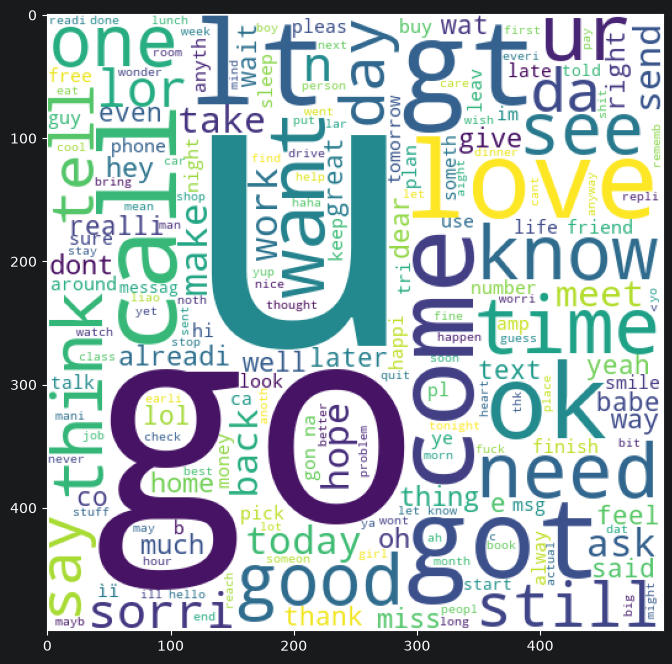

In [38]:
plt.figure(figsize=(10,8))
plt.imshow(ham_wc)

In [39]:
df.head()

,target,text,num_character,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [40]:
spam_corpus = []
for msg in df[df["target"] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)


In [41]:
len(spam_corpus)

9939

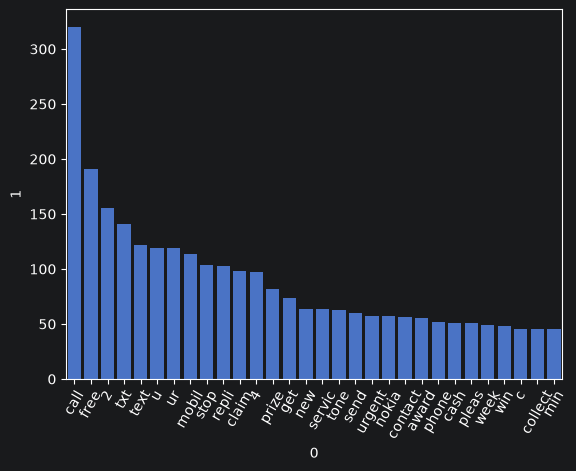

In [42]:
from collections import Counter

sns.barplot(
    x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0],
    y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1]
)
plt.xticks(rotation=60)
plt.show()


In [43]:
ham_corpus = []

for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

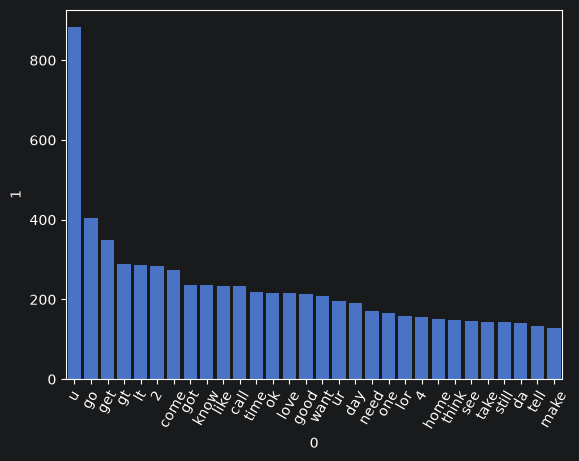

In [44]:
sns.barplot(
    x= pd.DataFrame(Counter(ham_corpus).most_common(30))[0],
    y= pd.DataFrame(Counter(ham_corpus).most_common(30))[1]
)
plt.xticks(rotation=60)
plt.show()

# 4.Model Building

In [77]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [78]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [79]:
X.shape

(5169, 3000)

In [80]:
y = df['target'].values

In [81]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [82]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [83]:
from sklearn.naive_bayes import GaussianNB ,MultinomialNB , BernoulliNB

In [84]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [68]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)

print("accuracy score :",round(accuracy_score(y_test,y_pred1) * 100 , 2),"%")
print("precision  score :",round(precision_score(y_test,y_pred1) * 100 , 2),"%")
print("confusion matrix :",confusion_matrix(y_test,y_pred1))

accuracy score : 86.94 %
precision  score : 50.68 %
confusion matrix : [[788 108]
 [ 27 111]]


In [85]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)

print(" accuracy score : ", round(accuracy_score(y_test,y_pred2)* 100 ,2 ), "%")
print(" precision score : ", round(precision_score(y_test,y_pred2) * 100,2) , "%")
print(" confusion matrix : ",confusion_matrix(y_test, y_pred2))

 accuracy score :  97.1 %
 precision score :  100.0 %
 confusion matrix :  [[896   0]
 [ 30 108]]


In [55]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)

print(" accuracy :", round(accuracy_score(y_test, y_pred3) * 100 ,2), " %")
print(" precision score: ",round(precision_score(y_test, y_pred3) * 100 ,2 ), "%")
print(" confusion matrix : ", confusion_matrix(y_test, y_pred3))

 accuracy : 98.36  %
 precision score:  99.19 %
 confusion matrix :  [[895   1]
 [ 16 122]]


In [56]:
# tfidf -> mnb

In [70]:
# checking if voting classifier can improve accuracy or precision

from sklearn.ensemble import VotingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

mnb = MultinomialNB()
rf = RandomForestClassifier()
svc = SVC()

estimator = [
    ('mnb', mnb),
    ('rf' , rf),
    ('svc', svc)
]

voting = VotingClassifier(
    estimators=estimator,
    voting='hard'
)

voting.fit(X_train,y_train)
y_pred4 = voting.predict(X_test)


print(" accuracy :", round(accuracy_score(y_test, y_pred4) * 100 ,2), " %")
print(" precision score: ",round(precision_score(y_test, y_pred4) * 100 ,2 ), "%")
print(" confusion matrix : ", confusion_matrix(y_test, y_pred4))

 accuracy : 97.58  %
 precision score:  100.0 %
 confusion matrix :  [[896   0]
 [ 25 113]]


In [71]:
# checking if stacking can improve accuracy or precision

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

mnb = MultinomialNB()
rf = RandomForestClassifier()
svc = SVC()

estimator = [
    ('mnb', mnb),
    ('rf' , rf),
    ('svc', svc)
]

stacking = StackingClassifier(
    estimators=estimator,
    final_estimator=LinearRegression()
)

voting.fit(X_train,y_train)
y_pred4 = voting.predict(X_test)


print(" accuracy :", round(accuracy_score(y_test, y_pred4) * 100 ,2), " %")
print(" precision score: ",round(precision_score(y_test, y_pred4) * 100 ,2 ), "%")
print(" confusion matrix : ", confusion_matrix(y_test, y_pred4))

 accuracy : 97.68  %
 precision score:  100.0 %
 confusion matrix :  [[896   0]
 [ 24 114]]


In [86]:
df.to_csv("spam_dataset_improved.csv",index=False)

In [88]:
import  pickle
pickle.dump(tfidf, open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('Model.pkl','wb'))

